<a href="https://colab.research.google.com/github/Imashaidk/sales-forecasting-project/blob/main/sales_forecasting_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle competitions download -c m5-forecasting-accuracy
!unzip -q m5-forecasting-accuracy.zip -d m5_data

100% 45.8M/45.8M [00:03<00:00, 12.5MB/s]



In [ ]:
!rm -rf m5_data
!unzip -q m5-forecasting-accuracy.zip -d m5_data

In [ ]:
import pandas as pd

sales = pd.read_csv('m5_data/sales_train_evaluation.csv')
calendar = pd.read_csv('m5_data/calendar.csv')
prices = pd.read_csv('m5_data/sell_prices.csv')

print(sales.shape)
sales.head()

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [ ]:
# Melt from wide to long format
sales_long = sales.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

print(sales_long.shape)
sales_long.head()

(59181090, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [ ]:
# Reduce memory: convert 'sales' and the 'd' number to smaller data types
sales_long['sales'] = sales_long['sales'].astype('int16')

# Merge with calendar to get real dates
sales_long = sales_long.merge(calendar[['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']], on='d', how='left')

print(sales_long.shape)
sales_long.head()

In [ ]:
import pandas as pd

sales = pd.read_csv('m5_data/sales_train_evaluation.csv')
calendar = pd.read_csv('m5_data/calendar.csv')

In [ ]:
# Downcast the day columns to a smaller number type BEFORE reshaping
d_cols = [c for c in sales.columns if c.startswith('d_')]
sales[d_cols] = sales[d_cols].astype('int16')

print("Memory after downcasting:", sales.memory_usage(deep=True).sum() / 1e6, "MB")

Memory after downcasting: 129.246532 MB


In [ ]:
sales_ca = sales[sales['state_id'] == 'CA'].copy()
print(sales_ca.shape)

(12196, 1947)


In [ ]:
sales_long = sales_ca.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)
print(sales_long.shape)
sales_long.head()

(23672436, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [ ]:
sales_long = sales_long.merge(
    calendar[['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA']],
    on='d', how='left'
)

print(sales_long.shape)
sales_long.head()

(23672436, 12)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,event_name_1,snap_CA
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0


In [ ]:
sales_long.to_csv('sales_long_ca.csv', index=False)

In [ ]:
from google.colab import files
files.download('sales_long_ca.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

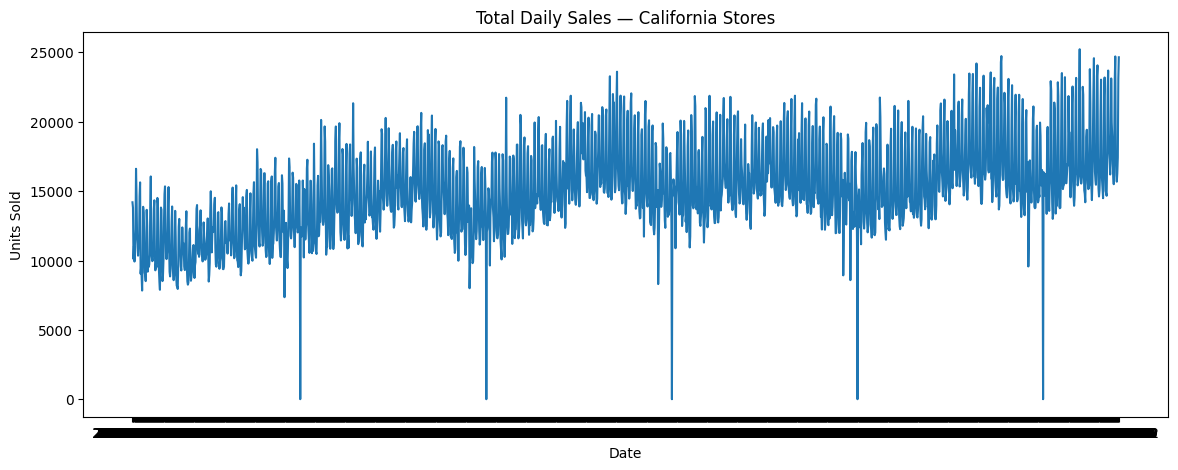

In [ ]:
import matplotlib.pyplot as plt

# Add up sales across all CA products, per day
daily_totals = sales_long.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_totals['date'], daily_totals['sales'])
plt.title('Total Daily Sales — California Stores')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

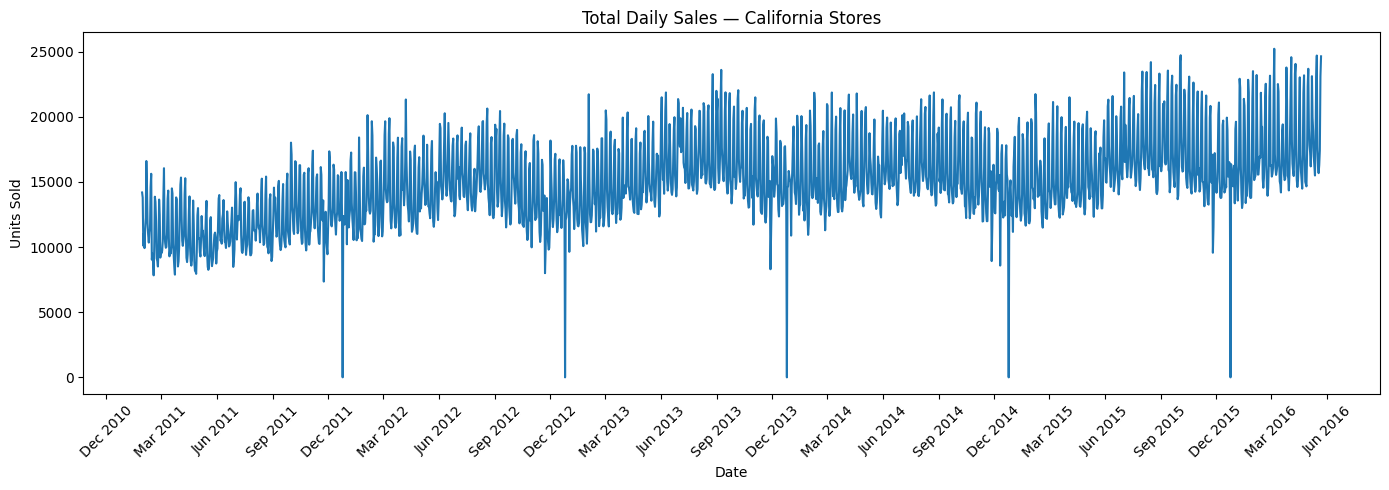

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_totals['date'], daily_totals['sales'])
ax.set_title('Total Daily Sales — California Stores')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')

# Only show a date label every 3 months, formatted cleanly
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

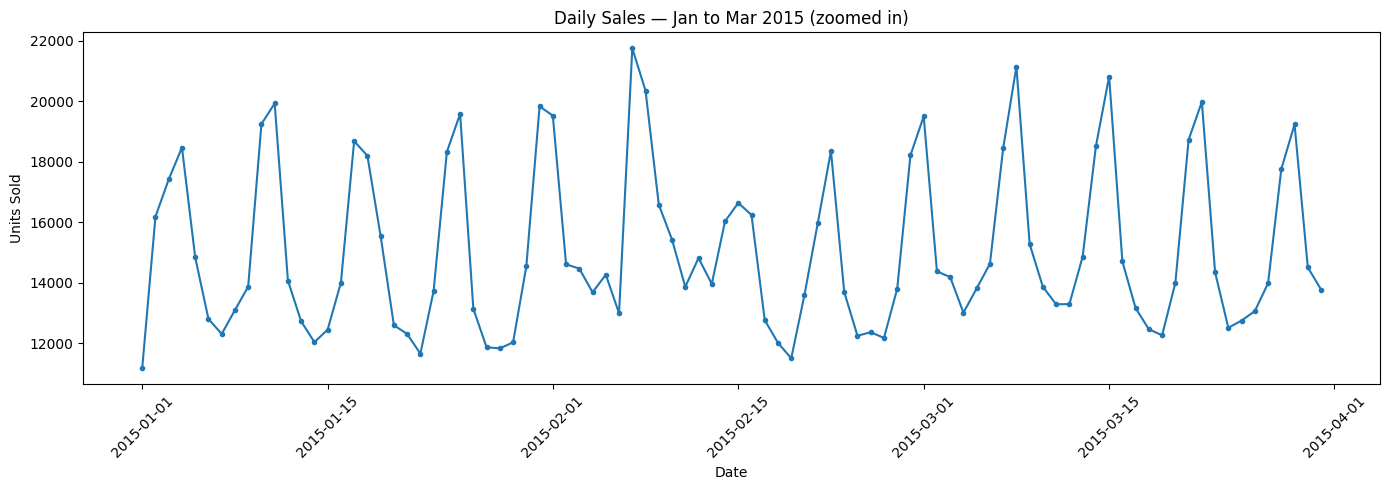

In [ ]:
daily_totals['date'] = pd.to_datetime(daily_totals['date'])
recent = daily_totals[(daily_totals['date'] >= '2015-01-01') & (daily_totals['date'] <= '2015-03-31')]

plt.figure(figsize=(14, 5))
plt.plot(recent['date'], recent['sales'], marker='o', markersize=3)
plt.title('Daily Sales — Jan to Mar 2015 (zoomed in)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

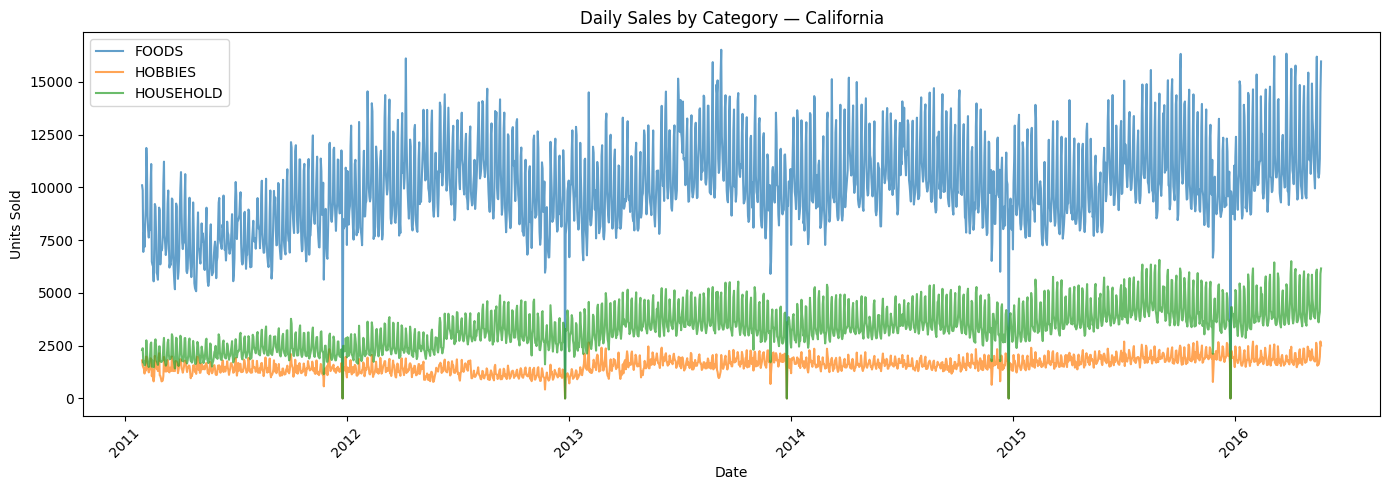

In [ ]:
# Total sales per day, split by category
category_daily = sales_long.groupby(['date', 'cat_id'])['sales'].sum().reset_index()
category_daily['date'] = pd.to_datetime(category_daily['date'])

plt.figure(figsize=(14, 5))
for cat in category_daily['cat_id'].unique():
    subset = category_daily[category_daily['cat_id'] == cat]
    plt.plot(subset['date'], subset['sales'], label=cat, alpha=0.7)

plt.title('Daily Sales by Category — California')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

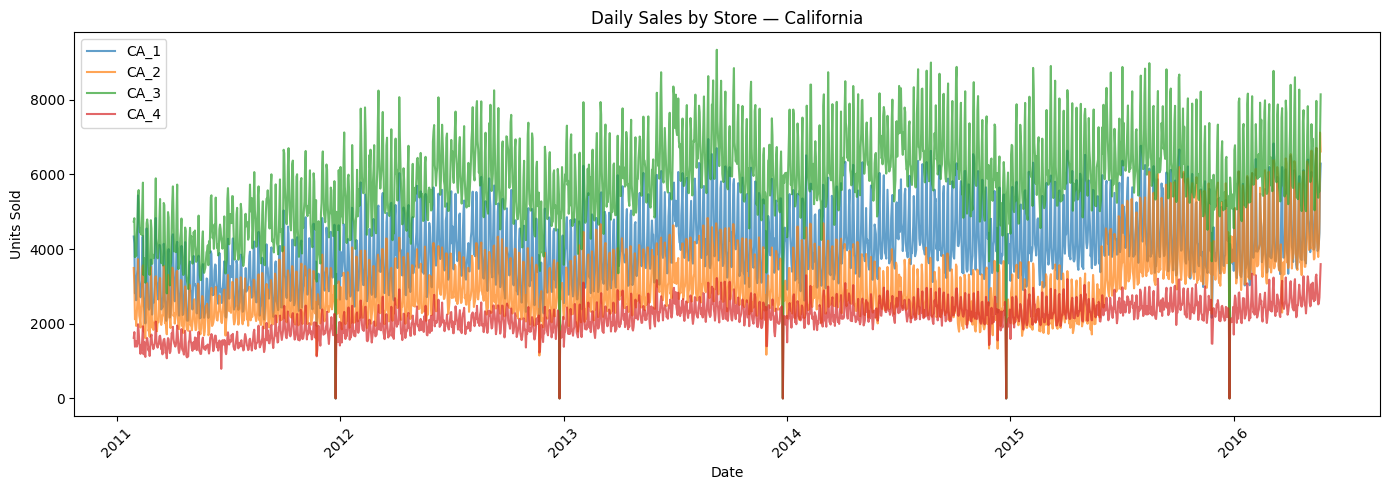

In [ ]:
store_daily = sales_long.groupby(['date', 'store_id'])['sales'].sum().reset_index()
store_daily['date'] = pd.to_datetime(store_daily['date'])

plt.figure(figsize=(14, 5))
for store in store_daily['store_id'].unique():
    subset = store_daily[store_daily['store_id'] == store]
    plt.plot(subset['date'], subset['sales'], label=store, alpha=0.7)

plt.title('Daily Sales by Store — California')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

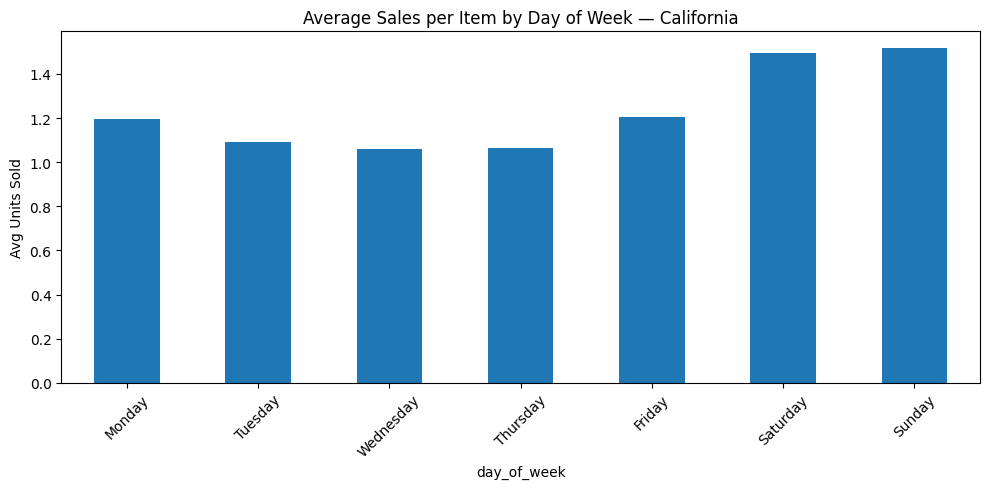

In [ ]:
sales_long['date'] = pd.to_datetime(sales_long['date'])
sales_long['day_of_week'] = sales_long['date'].dt.day_name()

dow_avg = sales_long.groupby('day_of_week')['sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10, 5))
dow_avg.plot(kind='bar')
plt.title('Average Sales per Item by Day of Week — California')
plt.ylabel('Avg Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
prices = pd.read_csv('m5_data/sell_prices.csv')
print(prices.shape)
prices.head()

(6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [ ]:
# Merge in prices — matched by item, store, and the week
sales_long = sales_long.merge(
    prices[prices['store_id'].isin(['CA_1','CA_2','CA_3','CA_4'])],
    on=['item_id', 'store_id', 'wm_yr_wk'],
    how='left'
)

print(sales_long.shape)
sales_long[['item_id', 'store_id', 'date', 'sales', 'sell_price']].head()

NameError: name 'sales_long' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload raw files
sales = pd.read_csv('m5_data/sales_train_evaluation.csv')
calendar = pd.read_csv('m5_data/calendar.csv')
prices = pd.read_csv('m5_data/sell_prices.csv')

# Downcast day columns to save memory
d_cols = [c for c in sales.columns if c.startswith('d_')]
sales[d_cols] = sales[d_cols].astype('int16')

# Filter to California only
sales_ca = sales[sales['state_id'] == 'CA'].copy()

# Melt wide to long
sales_long = sales_ca.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

# Merge calendar (dates, events, snap)
sales_long = sales_long.merge(
    calendar[['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA']],
    on='d', how='left'
)

# Merge prices
sales_long = sales_long.merge(
    prices[prices['store_id'].isin(['CA_1','CA_2','CA_3','CA_4'])],
    on=['item_id', 'store_id', 'wm_yr_wk'],
    how='left'
)

print(sales_long.shape)
sales_long[['item_id', 'store_id', 'date', 'sales', 'sell_price']].head()

(23672436, 13)


,item_id,store_id,date,sales,sell_price
0,HOBBIES_1_001,CA_1,2011-01-29,0,NaN
1,HOBBIES_1_002,CA_1,2011-01-29,0,NaN
2,HOBBIES_1_003,CA_1,2011-01-29,0,NaN
3,HOBBIES_1_004,CA_1,2011-01-29,0,NaN
4,HOBBIES_1_005,CA_1,2011-01-29,0,NaN


In [ ]:
# Check one item's price history over time — does NaN eventually become a real price?
check_item = sales_long[(sales_long['item_id'] == 'HOBBIES_1_001') & (sales_long['store_id'] == 'CA_1')].copy()
check_item['date'] = pd.to_datetime(check_item['date'])
check_item = check_item.sort_values('date')

# Show the first row where price actually appears
first_priced = check_item[check_item['sell_price'].notna()].head(3)
print(first_priced[['date', 'sales', 'sell_price']])

# And overall: what % of rows have no price?
print("\n% missing price:", sales_long['sell_price'].isna().mean() * 100)

               date  sales  sell_price
10927616 2013-07-13      0        9.58
10939812 2013-07-14      0        9.58
10952008 2013-07-15      0        9.58

% missing price: 21.59959372157559


In [ ]:
# Remove rows before a product was actually being sold (no price = not stocked)
before_count = len(sales_long)
sales_long = sales_long[sales_long['sell_price'].notna()].copy()
after_count = len(sales_long)

print(f"Removed {before_count - after_count:,} rows ({(before_count-after_count)/before_count*100:.1f}%)")
print(f"Remaining: {after_count:,} rows")

Removed 5,113,150 rows (21.6%)
Remaining: 18,559,286 rows


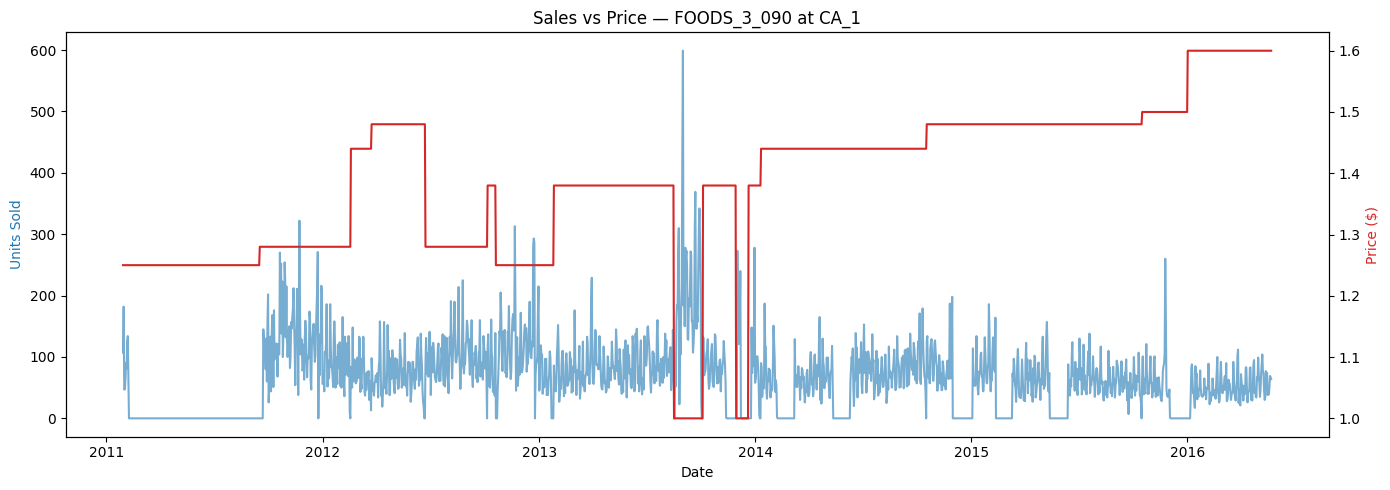

In [ ]:
sample_item = 'FOODS_3_090'  # a high-volume food item, good for visibility
sample = sales_long[(sales_long['item_id'] == sample_item) & (sales_long['store_id'] == 'CA_1')].copy()
sample['date'] = pd.to_datetime(sample['date'])
sample = sample.sort_values('date')

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(sample['date'], sample['sales'], color='tab:blue', alpha=0.6, label='Sales')
ax1.set_ylabel('Units Sold', color='tab:blue')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(sample['date'], sample['sell_price'], color='tab:red', label='Price')
ax2.set_ylabel('Price ($)', color='tab:red')

plt.title(f'Sales vs Price — {sample_item} at CA_1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average % of zero-sales days per item: 57.3

Distribution:
count    3049.000000
mean       57.333672
std        21.212329
min         0.321999
25%        42.017908
50%        58.896797
75%        74.489376
max        96.266667
Name: sales, dtype: float64


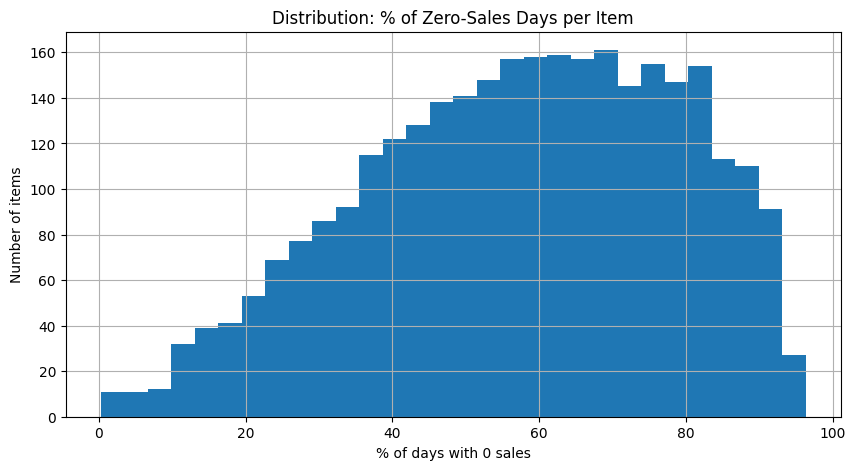

In [ ]:
# What % of days does each item have zero sales?
zero_pct = sales_long.groupby('item_id')['sales'].apply(lambda x: (x == 0).mean() * 100)

print("Average % of zero-sales days per item:", zero_pct.mean().round(1))
print("\nDistribution:")
print(zero_pct.describe())

plt.figure(figsize=(10, 5))
zero_pct.hist(bins=30)
plt.title('Distribution: % of Zero-Sales Days per Item')
plt.xlabel('% of days with 0 sales')
plt.ylabel('Number of items')
plt.show()

In [ ]:
sales_long['date'] = pd.to_datetime(sales_long['date'])

sales_long['day_of_week_num'] = sales_long['date'].dt.dayofweek  # Monday=0 ... Sunday=6
sales_long['is_weekend'] = sales_long['day_of_week_num'].isin([5, 6]).astype(int)
sales_long['month'] = sales_long['date'].dt.month
sales_long['year'] = sales_long['date'].dt.year

sales_long[['date', 'day_of_week_num', 'is_weekend', 'month', 'year']].head(10)

,date,day_of_week_num,is_weekend,month,year
7,2011-01-29,5,1,1,2011
8,2011-01-29,5,1,1,2011
9,2011-01-29,5,1,1,2011
11,2011-01-29,5,1,1,2011
14,2011-01-29,5,1,1,2011
15,2011-01-29,5,1,1,2011
21,2011-01-29,5,1,1,2011
22,2011-01-29,5,1,1,2011
27,2011-01-29,5,1,1,2011
28,2011-01-29,5,1,1,2011


In [ ]:
# Sort so lag calculations are correct (must be ordered by item+store, then date)
sales_long = sales_long.sort_values(['id', 'date']).reset_index(drop=True)

# Create lag features: sales from 7 and 28 days ago, per item-store
sales_long['lag_7'] = sales_long.groupby('id')['sales'].shift(7)
sales_long['lag_28'] = sales_long.groupby('id')['sales'].shift(28)

sales_long[['id', 'date', 'sales', 'lag_7', 'lag_28']].head(35)

,id,date,sales,lag_7,lag_28
0,FOODS_1_001_CA_1_evaluation,2011-01-29,3,NaN,NaN
1,FOODS_1_001_CA_1_evaluation,2011-01-30,0,NaN,NaN
2,FOODS_1_001_CA_1_evaluation,2011-01-31,0,NaN,NaN
3,FOODS_1_001_CA_1_evaluation,2011-02-01,1,NaN,NaN
4,FOODS_1_001_CA_1_evaluation,2011-02-02,4,NaN,NaN
5,FOODS_1_001_CA_1_evaluation,2011-02-03,2,NaN,NaN
6,FOODS_1_001_CA_1_evaluation,2011-02-04,0,NaN,NaN
7,FOODS_1_001_CA_1_evaluation,2011-02-05,2,3.0,NaN
8,FOODS_1_001_CA_1_evaluation,2011-02-06,0,0.0,NaN
9,FOODS_1_001_CA_1_evaluation,2011-02-07,0,0.0,NaN


In [ ]:
# Rolling averages: average sales over the past 7 and 28 days (using only past data, not today)
sales_long['rolling_mean_7'] = sales_long.groupby('id')['sales'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)
sales_long['rolling_mean_28'] = sales_long.groupby('id')['sales'].transform(
    lambda x: x.shift(1).rolling(window=28).mean()
)

sales_long[['id', 'date', 'sales', 'lag_7', 'rolling_mean_7', 'rolling_mean_28']].head(35)

,id,date,sales,lag_7,rolling_mean_7,rolling_mean_28
0,FOODS_1_001_CA_1_evaluation,2011-01-29,3,NaN,NaN,NaN
1,FOODS_1_001_CA_1_evaluation,2011-01-30,0,NaN,NaN,NaN
2,FOODS_1_001_CA_1_evaluation,2011-01-31,0,NaN,NaN,NaN
3,FOODS_1_001_CA_1_evaluation,2011-02-01,1,NaN,NaN,NaN
4,FOODS_1_001_CA_1_evaluation,2011-02-02,4,NaN,NaN,NaN
5,FOODS_1_001_CA_1_evaluation,2011-02-03,2,NaN,NaN,NaN
6,FOODS_1_001_CA_1_evaluation,2011-02-04,0,NaN,NaN,NaN
7,FOODS_1_001_CA_1_evaluation,2011-02-05,2,3.0,1.428571,NaN
8,FOODS_1_001_CA_1_evaluation,2011-02-06,0,0.0,1.285714,NaN
9,FOODS_1_001_CA_1_evaluation,2011-02-07,0,0.0,1.285714,NaN


In [ ]:
# Price features: current price, and whether price just dropped (a promo signal)
sales_long = sales_long.sort_values(['id', 'date']).reset_index(drop=True)

sales_long['price_lag_1'] = sales_long.groupby('id')['sell_price'].shift(1)
sales_long['price_drop'] = (sales_long['sell_price'] < sales_long['price_lag_1']).astype(int)

sales_long[['id', 'date', 'sell_price', 'price_lag_1', 'price_drop']].head(20)

,id,date,sell_price,price_lag_1,price_drop
0,FOODS_1_001_CA_1_evaluation,2011-01-29,2.0,NaN,0
1,FOODS_1_001_CA_1_evaluation,2011-01-30,2.0,2.0,0
2,FOODS_1_001_CA_1_evaluation,2011-01-31,2.0,2.0,0
3,FOODS_1_001_CA_1_evaluation,2011-02-01,2.0,2.0,0
4,FOODS_1_001_CA_1_evaluation,2011-02-02,2.0,2.0,0
5,FOODS_1_001_CA_1_evaluation,2011-02-03,2.0,2.0,0
6,FOODS_1_001_CA_1_evaluation,2011-02-04,2.0,2.0,0
7,FOODS_1_001_CA_1_evaluation,2011-02-05,2.0,2.0,0
8,FOODS_1_001_CA_1_evaluation,2011-02-06,2.0,2.0,0
9,FOODS_1_001_CA_1_evaluation,2011-02-07,2.0,2.0,0
